In [1]:
import os.path as osp
import sys
sys.path.append('../')
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

import numpy as np
from tqdm.notebook import tqdm
#from sklearn import preprocessing, metrics
import types

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import utils

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


/home/mdrnevich/DESY/dev/ml4nw/ToyModels/../utils/__init__.py:3: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. 

  from . import plotting


In [2]:
"""
Dataset options: pos_only, mc, negative
"""

DATASET = "mc"


source_mixture_coef = (4, -1)
source_scales = (2.5, 2.3)
target_mixture_coef = (2, -1)
if DATASET == "negative":
    target_scales = (2, 1.2)
else:
    target_scales = (2, 1.42)


if DATASET == "pos_only":
    model_base_type = "mc"
    source_file = "./data/base_gaussian_distribution_data"
    target_file = "./data/target_camel_distribution_data"
elif DATASET == "mc":
    model_base_type = "mc"
    source_file = "./data/base_gaussian_distribution_mc_data"
    target_file = "./data/target_camel_distribution_mc_data"
elif DATASET == "negative":
    model_base_type = "negative"
    source_file = "./data/base_gaussian_distribution_mc_data"
    target_file = "./data/target_negative_camel_distribution_mc_data"

In [3]:
batch_size = int(2**8)
model_paths = [osp.join("models/classifier_{}_subdensity_{}_batch{}.zip".format(model_base_type, i+1, batch_size)) for i in range(4)]
training_settings = [utils.train.load_training_settings(model_path) for model_path in model_paths]
X_scalers, weight_norms = list(zip(*[utils.preprocessing.load_scaling(model_path) for model_path in model_paths]))
models = [utils.models.load_model(model_path, device=DEVICE).to(DEVICE) for model_path in model_paths]

In [4]:
source_positive_file = source_file + "_positives"
source_negative_file = source_file + "_negatives"
target_positive_file = target_file + "_positives"
target_negative_file = target_file + "_negatives"

files = [source_positive_file, source_negative_file, target_positive_file, target_negative_file]

sum_weights = []
for f in files:
    sum_weights.append(np.load(f + "_train.npy")[:,-1].sum())

sum_weights = np.array(sum_weights)
sum_weights

array([1598937., -401063., 1333494., -666506.])

In [5]:
coefficient_init = [sum_weights[0] / sum_weights[:2].sum(), sum_weights[2] / sum_weights[2:].sum()]
coefficient_init

[1.3348123425335219, 1.9992773483181108]

In [6]:
training_settings = {}

"""
There is one dataset generated using Powheg + Pythia8
and another generated using Sherpa
"""

t0 = 25619
t1 = 58
print(t0, t1, -(t0/t1)**2, -t0/t1)


MIN_TRAIN_SIZE = int(min([np.load(source_file + "_train.npy").shape[0], np.load(target_file + "_train.npy").shape[0]]))
MIN_VALID_SIZE = int(min([np.load(source_file + "_val.npy").shape[0], np.load(target_file + "_val.npy").shape[0]]))

train_base_dataset = utils.preprocessing.Dataset(source_file + "_train.npy", 0, stop_event=MIN_TRAIN_SIZE)
valid_base_dataset = utils.preprocessing.Dataset(source_file + "_val.npy", 0, stop_event=MIN_VALID_SIZE)

train_target_dataset = utils.preprocessing.Dataset(target_file + "_train.npy", 1, stop_event=MIN_TRAIN_SIZE)
valid_target_dataset = utils.preprocessing.Dataset(target_file + "_val.npy", 1, stop_event=MIN_VALID_SIZE)


training_settings.update({
    "source_file": source_file,
    "target_file": target_file,
})

25619 58 -195104.9824613555 -441.7068965517241


In [7]:
source_weight_norm = train_base_dataset.process(normalize_weights=True)
valid_base_dataset.process(normalize_weights=True)#, weight_norm=source_weight_norm)

target_weight_norm = train_target_dataset.process(normalize_weights=True)
valid_target_dataset.process(normalize_weights=True)#, weight_norm=target_weight_norm)

tensor(0.3334)

In [8]:
train_generator_data = utils.preprocessing.CombinedDataset(train_base_dataset, train_target_dataset)
valid_generator_data = utils.preprocessing.CombinedDataset(valid_base_dataset, valid_target_dataset)

In [9]:
X_scaler, weight_norm = utils.preprocessing.get_scaling(train_generator_data)
print(weight_norm)

100%|██████████| 3907/3907 [00:20<00:00, 192.55it/s]

tensor(1.0000)


In [10]:
@torch.no_grad()
def get_scores(model, loader, X_scaler, weight_norm=1, leave=False):
    if type(model) is not types.FunctionType:
        model.eval()
        loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_training(batch, X_scaler, weight_norm=weight_norm)
    else:
        loader.collate_fn = lambda batch: utils.preprocessing.prep_inputs_for_density(batch, weight_norm=weight_norm)

    score_list = []
    target_list = []
    weight_list = []
    t = tqdm(enumerate(loader), total=len(loader), leave=leave)
    for i, batch in t:
        target_list.append(batch[1])
        weight_list.append(batch[2])
        if type(model) is not types.FunctionType:
            x = batch[0].to(DEVICE)
        else:
            x = batch[0].to('cpu')
        batch_score = model(x)
        score_list.append(batch_score)
        t.refresh()  # to show immediately the update

    return torch.cat(score_list).cpu().numpy().flatten(), torch.cat(target_list).cpu().numpy().flatten(), torch.cat(weight_list).cpu().numpy().flatten()

In [11]:
batch_size = 1024
train_loader = DataLoader(train_generator_data, batch_size=batch_size, shuffle=False)
train_nominal_loader = DataLoader(utils.preprocessing.CombinedDataset(train_base_dataset), batch_size=batch_size, shuffle=False)
train_alternative_loader = DataLoader(utils.preprocessing.CombinedDataset(train_target_dataset), batch_size=batch_size, shuffle=False)

In [12]:
train_scores, train_targets, train_weights = list(zip(*[get_scores(
    models[i],
    train_loader,
    X_scalers[i],
    leave=True
) for i in range(4)]))

  0%|          | 0/3907 [00:00<?, ?it/s]

  0%|          | 0/3907 [00:00<?, ?it/s]

  0%|          | 0/3907 [00:00<?, ?it/s]

  0%|          | 0/3907 [00:00<?, ?it/s]

In [13]:
train_subratios = [(1-train_scores[i]) / train_scores[i] for i in range(4)]
targets = torch.from_numpy(train_targets[0])
weights = torch.from_numpy(train_weights[0]) / weight_norm

In [14]:
def get_total_ratio(c0, c1, ratios):
    part1 = (c0 / c1) * ratios[0]
    part2 = ((1 - c0) / c1) * ratios[2]
    part3 = (c0 / (1 - c1)) * ratios[1]
    part4 = ((1 - c0) / (1 - c1)) * ratios[3]
    total_ratio = 1/(part1+part2) + 1/(part3+part4)
    return total_ratio #q(Y=1)/q(Y=0)

In [15]:
def get_pare_loss(ratios, targets, weights, t0=t0, t1=t1):
    s = torch.from_numpy((t0 + t1 * ratios) / (t0**2 + t1**2 * ratios))
    return (utils.train.pare_loss(s, targets, t0, t1)*weights).mean().cpu().item()

def get_mse_loss(ratios, targets, weights):
    s = torch.from_numpy(ratios / (1 + ratios))
    return (F.mse_loss(s, targets, reduction='none')*weights).mean().cpu().item()

In [16]:
_ = get_total_ratio(*coefficient_init, train_subratios)
print(_.min(), _.max())
#np.testing.assert_almost_equal(1/_, _2)
_

0.006793633 1.5618355


array([0.6395569 , 1.2003802 , 1.05078   , ..., 1.1647253 , 1.1941816 ,
       0.16445374], dtype=float32)

In [17]:
print(max(abs(_)))

1.5618355


In [18]:
N = 30
pare_losses0 = np.zeros(N)
x = np.linspace(coefficient_init[0]-1, coefficient_init[0]+0.5, N)

for i, c0 in enumerate(x):
    ratios = get_total_ratio(c0, coefficient_init[1], train_subratios)
    #print(((t0 + t1 * ratios) / (t0**2 + t1**2 * ratios)).mean())
    pare_losses0[i] = get_pare_loss(ratios, targets, weights, t0=t0, t1=t1)
pare_losses0 = np.array(pare_losses0)

In [19]:
pare_vmin0 = np.argmin(np.nan_to_num(pare_losses0, nan=np.inf, neginf=np.inf))
x[pare_vmin0], pare_losses0[pare_vmin0]

(1.2141226873611082, 0.4977378585796234)

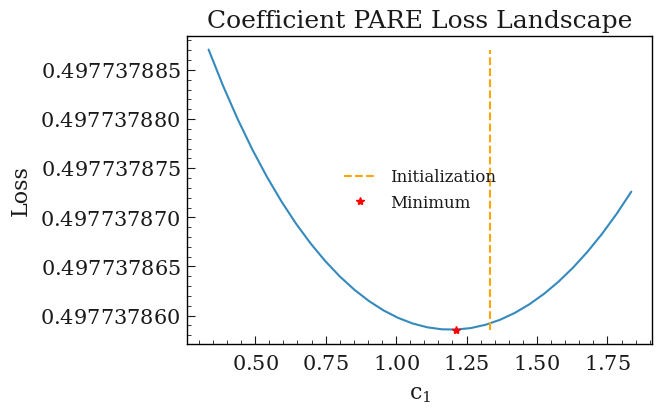

In [20]:
plt.plot(x, pare_losses0)
plt.plot([coefficient_init[0], coefficient_init[0]],
         [np.nan_to_num(pare_losses0, nan=np.inf, neginf=np.inf).min(),
          np.nan_to_num(pare_losses0, nan=-np.inf, posinf=-np.inf).max()], '--', c='orange', label="Initialization")
plt.plot(x[pare_vmin0], pare_losses0[pare_vmin0], '*', c='red', label="Minimum")
plt.xlabel("$c_1$", size=16)
plt.ylabel("Loss", size=16)
plt.title("Coefficient PARE Loss Landscape", size=18)
plt.legend()

In [21]:
N = 30
mse_losses0 = np.zeros(N)
x = np.linspace(coefficient_init[0]-1, coefficient_init[0]+0.5, N)

for i, c0 in enumerate(x):
    ratios = get_total_ratio(c0, coefficient_init[1], train_subratios)
    mse_losses0[i] = get_mse_loss(ratios, targets, weights)

mse_losses0 = np.array(mse_losses0)

In [22]:
mse_vmin0 = np.argmin(np.nan_to_num(mse_losses0, nan=np.inf, neginf=np.inf))
x[mse_vmin0], mse_losses0[mse_vmin0]

(1.1623985494300735, 0.2378656268119812)

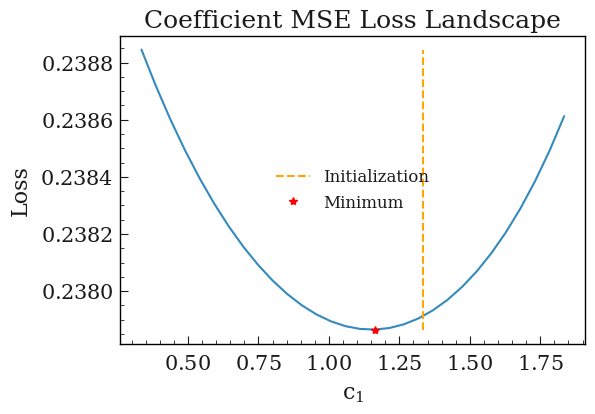

In [23]:
plt.plot(x, mse_losses0)
plt.plot([coefficient_init[0], coefficient_init[0]],
         [np.nan_to_num(mse_losses0, nan=np.inf, neginf=np.inf).min(),
          np.nan_to_num(mse_losses0, nan=-np.inf, posinf=-np.inf).max()], '--', c='orange', label="Initialization")
plt.plot(x[mse_vmin0], mse_losses0[mse_vmin0], '*', c='red', label="Minimum")
plt.xlabel("$c_1$", size=16)
plt.ylabel("Loss", size=16)
plt.title("Coefficient MSE Loss Landscape", size=18)
plt.legend()

In [24]:
N = 30
pare_losses1 = np.zeros(N)
y = np.linspace(coefficient_init[1]-1, coefficient_init[1]+1, N)

for i, c1 in enumerate(y):
    ratios = get_total_ratio(coefficient_init[0], c1, train_subratios)
    pare_losses1[i] = get_pare_loss(ratios, targets, weights, t0=t0, t1=t1)

pare_losses1 = np.array(pare_losses1)

In [25]:
pare_vmin1 = np.argmin(np.nan_to_num(pare_losses1, nan=np.inf, neginf=np.inf))
y[pare_vmin1]

1.964794589697421

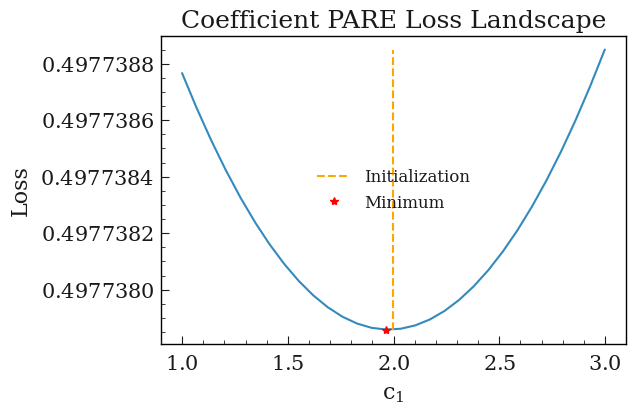

In [26]:
plt.plot(y, pare_losses1)
plt.plot([coefficient_init[1], coefficient_init[1]],
         [np.nan_to_num(pare_losses1, nan=np.inf, neginf=np.inf).min(),
          np.nan_to_num(pare_losses1, nan=-np.inf, posinf=-np.inf).max()], '--', c='orange', label="Initialization")
plt.plot(y[pare_vmin1], pare_losses1[pare_vmin1], '*', c='red', label="Minimum")
plt.xlabel("$c_1$", size=16)
plt.ylabel("Loss", size=16)
plt.title("Coefficient PARE Loss Landscape", size=18)
plt.legend()

## Do a 2D scan

In [29]:
N = 40
pare_losses = np.zeros((N,N))
x = np.linspace(coefficient_init[0]-1, coefficient_init[0]+1, N)
y = np.linspace(coefficient_init[1]-1, coefficient_init[1]+1, N)

for i, c0 in enumerate(x):
    for j, c1 in enumerate(y):
        ratios = get_total_ratio(c0, c1, train_subratios)
        pare_losses[i,j] = get_pare_loss(ratios, targets, weights, t0=t0, t1=t1)

pare_losses = np.array(pare_losses)

In [30]:
pare_vmin = np.nanmin(pare_losses[~np.isinf(pare_losses)])
pare_vmax = np.nanmax(pare_losses[~np.isinf(pare_losses)])
pare_vmin, pare_vmax

(0.49773785750919347, 0.4977392349262834)

In [31]:
pare_argmin = np.argmin(np.nan_to_num(pare_losses, nan=pare_vmax, posinf=pare_vmax, neginf=pare_vmax))
x[pare_argmin//N], y[pare_argmin%N]

(1.1553251630463424, 1.973636322677085)

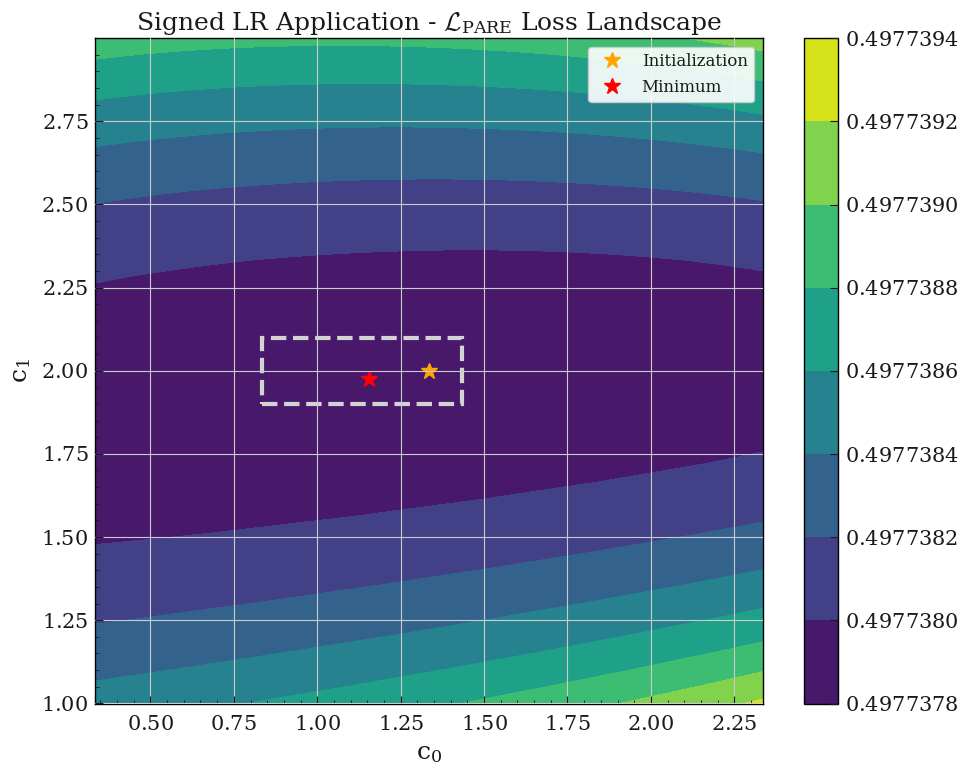

In [32]:
fig, ax = plt.subplots()
fig.set_size_inches(10,8)

xx, yy = np.meshgrid(x,y)
im = ax.contourf(xx, yy, pare_losses.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x[pare_argmin//N], y[pare_argmin%N], '*', c='red', label="Minimum", markersize='12')
rect = patches.Rectangle((coefficient_init[0]-0.5, coefficient_init[1]-0.1), 0.6, 0.2, linewidth=3, edgecolor='lightgray', linestyle='--', facecolor='none')
ax.add_patch(rect)
ax.set_xlabel('$c_0$')
ax.set_ylabel('$c_1$')
ax.set_title("Signed LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=18)
ax.grid()
ax.legend(frameon=True, framealpha=0.9)
fig.colorbar(im, ax=ax)

fig.tight_layout()

In [33]:
N = 40
mse_losses = np.zeros((N,N))
x = np.linspace(coefficient_init[0]-1, coefficient_init[0]+1, N)
y = np.linspace(coefficient_init[1]-1, coefficient_init[1]+1, N)

for i, c0 in enumerate(x):
    for j, c1 in enumerate(y):
        ratios = get_total_ratio(c0, c1, train_subratios)
        mse_losses[i,j] = get_mse_loss(ratios, targets, weights)

mse_losses = np.array(mse_losses)

/tmp/ipykernel_6673/74352892.py:6: RuntimeWarning: divide by zero encountered in divide
  s = torch.from_numpy(ratios / (1 + ratios))


In [34]:
mse_vmin = np.nanmin(mse_losses[~np.isinf(mse_losses)])
mse_vmax = np.nanmax(mse_losses[~np.isinf(mse_losses)])
mse_vmin, mse_vmax

(-11651524.0, 14886126.0)

In [35]:
mse_argmin = np.argmin(np.nan_to_num(mse_losses, nan=mse_vmax, posinf=mse_vmax, neginf=mse_vmax))
x[mse_argmin//N], y[mse_argmin%N]

(0.3348123425335219, 2.8454311944719564)

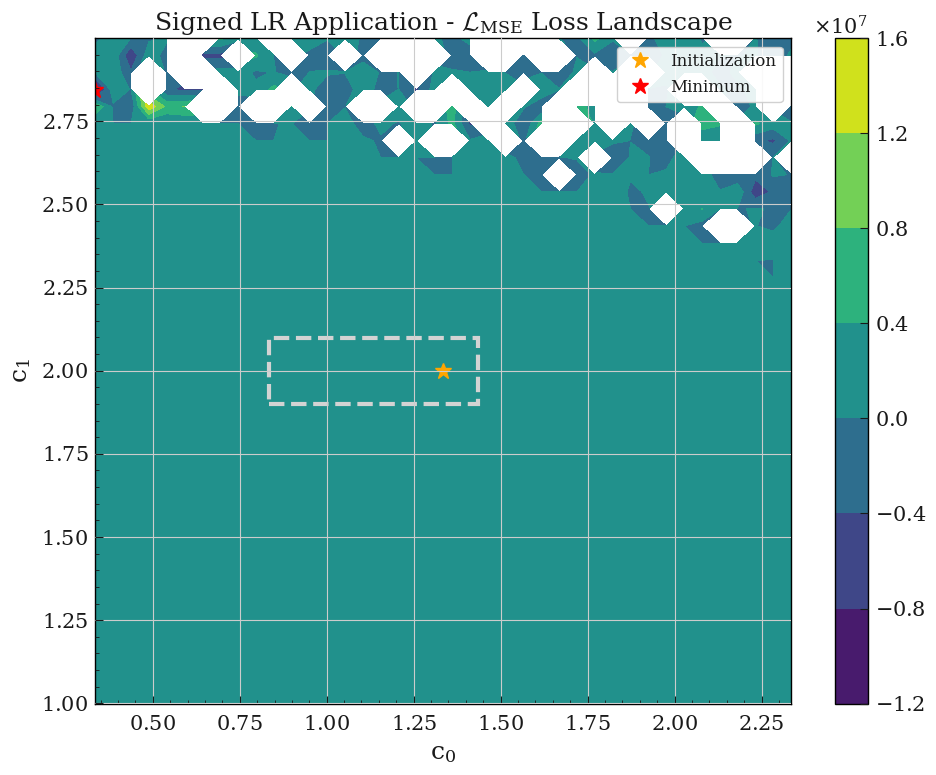

In [36]:
fig, ax = plt.subplots()
fig.set_size_inches(10,8)

xx, yy = np.meshgrid(x,y)
im = ax.contourf(xx, yy, mse_losses.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x[mse_argmin//N], y[mse_argmin%N], '*', c='red', label="Minimum", markersize='12')
rect = patches.Rectangle((coefficient_init[0]-0.5, coefficient_init[1]-0.1), 0.6, 0.2, linewidth=3, edgecolor='lightgray', linestyle='--', facecolor='none')
ax.add_patch(rect)
ax.set_xlabel('$c_0$')
ax.set_ylabel('$c_1$')
ax.set_title("Signed LR Application - $\mathcal{L}_{MSE}$ Loss Landscape", fontsize=18)
ax.grid()
ax.legend(frameon=True, framealpha=0.9)
fig.colorbar(im, ax=ax)

fig.tight_layout()

## Now do a zoomed-in version

In [37]:
N = 40
pare_losses2 = np.zeros((N,N))
x2 = np.linspace(coefficient_init[0]-0.5, coefficient_init[0]+0.1, N)
y2 = np.linspace(coefficient_init[1]-0.1, coefficient_init[1]+0.1, N)

for i, c0 in enumerate(x2):
    for j, c1 in enumerate(y2):
        ratios = get_total_ratio(c0, c1, train_subratios)
        pare_losses2[i,j] = get_pare_loss(ratios, targets, weights, t0=t0, t1=t1)

pare_losses2 = np.array(pare_losses2)

In [38]:
pare_vmin2 = np.nanmin(pare_losses2[~np.isinf(pare_losses2)])
pare_vmax2 = np.nanmax(pare_losses2[~np.isinf(pare_losses2)])
pare_vmin2, pare_vmax2

(0.4977378573283527, 0.4977378833430284)

In [39]:
pare_argmin2 = np.argmin(np.nan_to_num(pare_losses2, nan=pare_vmax2, posinf=pare_vmax2, neginf=pare_vmax2))
x2[pare_argmin2//N], y2[pare_argmin2%N]

(1.0963508040719834, 1.9556876047283671)

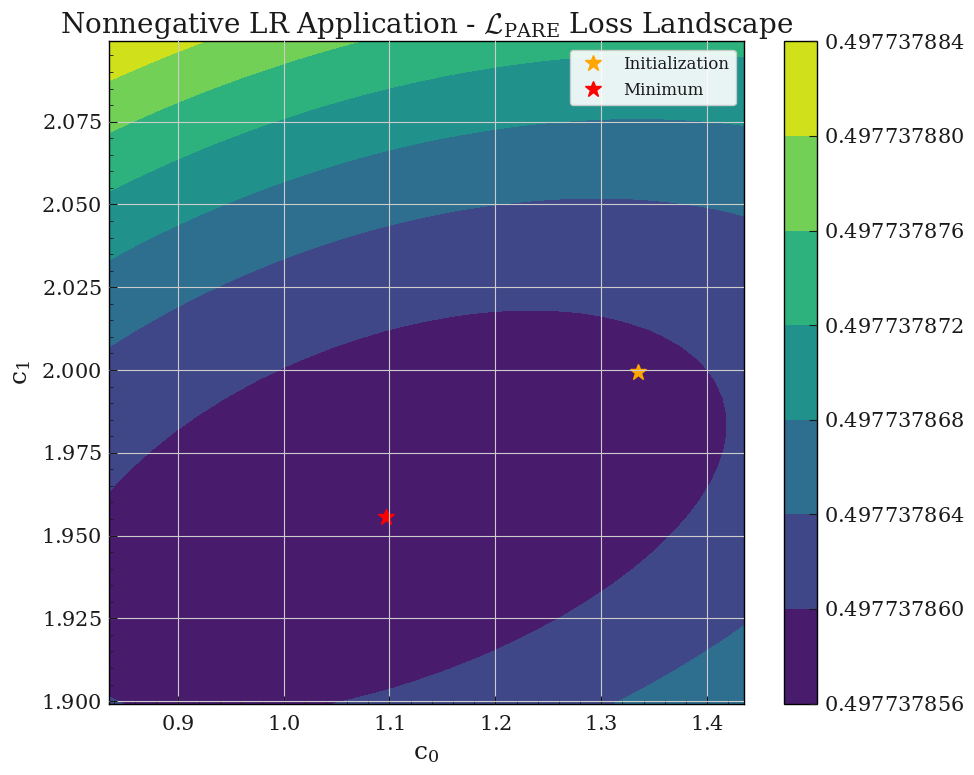

In [40]:
fig, ax = plt.subplots()
fig.set_size_inches(10,8)

xx, yy = np.meshgrid(x2,y2)
im = ax.contourf(xx, yy, pare_losses2.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x2[pare_argmin2//N], y2[pare_argmin2%N], '*', c='red', label="Minimum", markersize='12')
ax.set_xlabel('$c_0$')
ax.set_ylabel('$c_1$')
if DATASET == "negative":
    ax.set_title("Signed LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=20)
if DATASET == "mc":
    ax.set_title("Nonnegative LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=20)
ax.grid()
ax.legend(frameon=True, framealpha=0.9)
fig.colorbar(im, ax=ax)

fig.tight_layout()

In [41]:
N = 40
mse_losses2 = np.zeros((N,N))
x2 = np.linspace(coefficient_init[0]-0.5, coefficient_init[0]+0.1, N)
y2 = np.linspace(coefficient_init[1]-0.1, coefficient_init[1]+0.1, N)

for i, c0 in enumerate(x2):
    for j, c1 in enumerate(y2):
        ratios = get_total_ratio(c0, c1, train_subratios)
        mse_losses2[i,j] = get_mse_loss(ratios, targets, weights)

mse_losses2 = np.array(mse_losses2)

In [42]:
mse_vmin2 = np.nanmin(mse_losses2[~np.isinf(mse_losses2)])
mse_vmax2 = np.nanmax(mse_losses2[~np.isinf(mse_losses2)])
mse_vmin2, mse_vmax2

(0.23777735233306885, 0.23939287662506104)

In [43]:
mse_argmin2 = np.argmin(np.nan_to_num(mse_losses2, nan=mse_vmax2, posinf=mse_vmax2, neginf=mse_vmax2))
x2[mse_argmin2//N], y2[mse_argmin2%N]

(1.080966188687368, 1.9608158098565722)

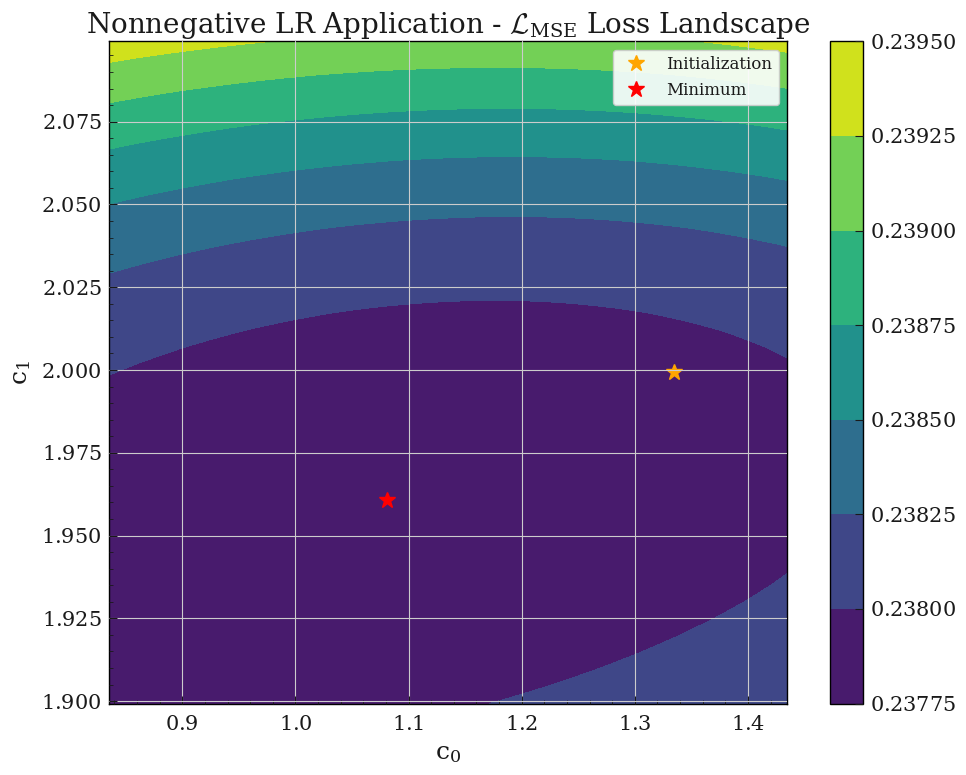

In [44]:
fig, ax = plt.subplots()
fig.set_size_inches(10,8)

xx, yy = np.meshgrid(x2,y2)
im = ax.contourf(xx, yy, mse_losses2.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x2[mse_argmin2//N], y2[mse_argmin2%N], '*', c='red', label="Minimum", markersize='12')
ax.set_xlabel('$c_0$')
ax.set_ylabel('$c_1$')
if DATASET == "negative":
    ax.set_title("Signed LR Application - $\mathcal{L}_{MSE}$ Loss Landscape", fontsize=20)
if DATASET == "mc":
    ax.set_title("Nonnegative LR Application - $\mathcal{L}_{MSE}$ Loss Landscape", fontsize=20)
ax.grid()
ax.legend(frameon=True, framealpha=0.9)
fig.colorbar(im, ax=ax)

fig.tight_layout()

## Make projection plots

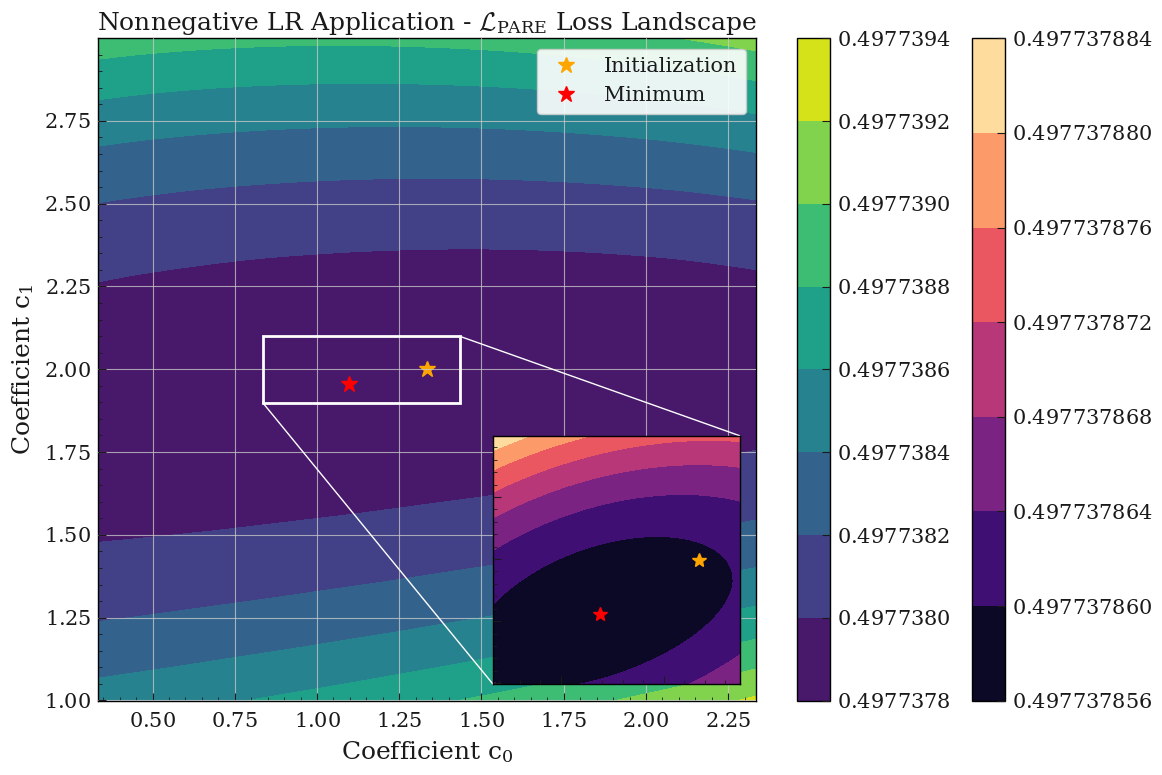

In [45]:
fig, ax = plt.subplots()
fig.set_size_inches(12,8)

xx, yy = np.meshgrid(x,y)
im = ax.contourf(xx, yy, pare_losses.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x2[pare_argmin2//N], y2[pare_argmin2%N], '*', c='red', label="Minimum", markersize='12')

axins = ax.inset_axes(
    [x.max()-0.8, y.min()+0.05, 0.75, 0.75],
    xlim=(x2.min(), x2.max()), ylim=(y2.min(), y2.max()),
    xticklabels=[], yticklabels=[], transform=ax.transData
)

xx2, yy2 = np.meshgrid(x2,y2)
im2 = axins.contourf(xx2, yy2, pare_losses2.T, cmap=matplotlib.colormaps['magma'])#, levels=np.linspace(-1e6, 1e6, 15))
axins.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='10')
axins.plot(x2[pare_argmin2//N], y2[pare_argmin2%N], '*', c='red', label="Minimum", markersize='10')
ax.indicate_inset_zoom(axins, edgecolor="white", linewidth=2, alpha=1)

ax.set_xlabel('Coefficient $c_0$', fontsize=18)
ax.set_ylabel('Coefficient $c_1$', fontsize=18)
if DATASET == "negative":
    ax.set_title("Signed LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=20)
if DATASET == "mc":
    ax.set_title("Nonnegative LR Application - $\mathcal{L}_{PARE}$ Loss Landscape", fontsize=18)
ax.grid(alpha=0.75)
ax.legend(frameon=True, framealpha=0.9, fontsize=15)
fig.colorbar(im2, ax=ax)
fig.colorbar(im, ax=ax)

fig.tight_layout()
if DATASET == "mc":
    fig.savefig("Toy_prob_pare_loss_landscape_inset.pdf")
if DATASET == "negative":
    fig.savefig("Toy_quasi_pare_loss_landscape_inset.pdf")

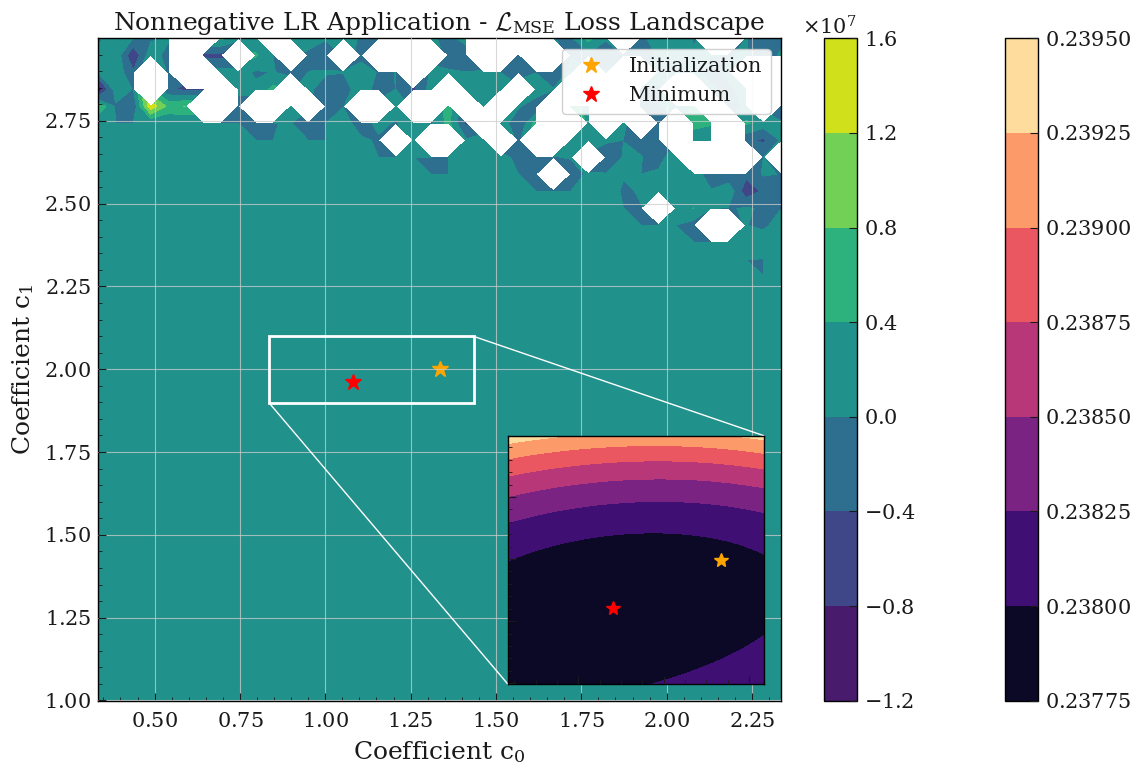

In [46]:
fig, ax = plt.subplots()
fig.set_size_inches(12,8)

xx, yy = np.meshgrid(x,y)
im = ax.contourf(xx, yy, mse_losses.T)#, levels=np.linspace(-1e6, 1e6, 15))
ax.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='12')
ax.plot(x2[mse_argmin2//N], y2[mse_argmin2%N], '*', c='red', label="Minimum", markersize='12')

axins = ax.inset_axes(
    [x.max()-0.8, y.min()+0.05, 0.75, 0.75],
    xlim=(x2.min(), x2.max()), ylim=(y2.min(), y2.max()),
    xticklabels=[], yticklabels=[], transform=ax.transData
)

xx2, yy2 = np.meshgrid(x2,y2)
im2 = axins.contourf(xx2, yy2, mse_losses2.T, cmap=matplotlib.colormaps['magma'])#, levels=np.linspace(-1e6, 1e6, 15))
axins.plot(*coefficient_init, '*', c='orange', label="Initialization", markersize='10')
axins.plot(x2[mse_argmin2//N], y2[mse_argmin2%N], '*', c='red', label="Minimum", markersize='10')
ax.indicate_inset_zoom(axins, edgecolor="white", linewidth=2, alpha=1)

ax.set_xlabel('Coefficient $c_0$', fontsize=18)
ax.set_ylabel('Coefficient $c_1$', fontsize=18)
if DATASET == "negative":
    ax.set_title("Signed LR Application - $\mathcal{L}_{MSE}$ Loss Landscape", fontsize=20)
if DATASET == "mc":
    ax.set_title("Nonnegative LR Application - $\mathcal{L}_{MSE}$ Loss Landscape", fontsize=18)
ax.grid(alpha=0.75)
ax.legend(frameon=True, framealpha=0.9, fontsize=15)
fig.colorbar(im2, ax=ax)
fig.colorbar(im, ax=ax)

fig.tight_layout()
if DATASET == "mc":
    fig.savefig("Toy_prob_mse_loss_landscape_inset.pdf")
if DATASET == "negative":
    fig.savefig("Toy_quasi_mse_loss_landscape_inset.pdf")